In [ ]:
import networkx as nx
import pandas as pd
import itertools
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np

In [ ]:
# Load data
cities = pd.read_csv("network_nodes_car.csv")          # columns: name, station, lat, lon
connections = pd.read_csv("network_edges_car.csv")  # columns: from, to

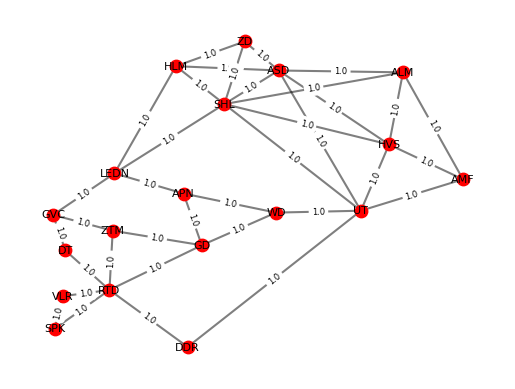

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

# Make sure lat/lng are numeric
cities["lat"] = pd.to_numeric(cities["lat"], errors="coerce")
cities["lng"] = pd.to_numeric(cities["lng"], errors="coerce")

# Drop rows with missing coordinates
cities = cities.dropna(subset=["lat", "lng"])

# Create the graph
G = nx.Graph()

# Add nodes with coordinates and station info
for _, row in cities.iterrows():
    G.add_node(
        row["name"],
        station=row.get("station", None),
        lat=row["lat"],
        lon=row["lng"]
    )

# Add edges, ensuring no duplicates
seen_edges = set()
for _, row in connections.iterrows():
    a, b = row["from"], row["to"]
    if a in G and b in G and a != b:
        edge = tuple(sorted([a, b]))
        if edge not in seen_edges:
            weight = row.get("time", 1)  # optional: use weight if present
            G.add_edge(a, b, weight=weight)
            seen_edges.add(edge)

# Define positions based on coordinates
pos = {row["name"]: (row["lng"], row["lat"]) for _, row in cities.iterrows()}

# Draw graph nodes and edges
nx.draw_networkx_edges(G, pos, alpha=0.5, width=1.5)
nx.draw_networkx_nodes(G, pos, node_size=80, node_color="red")
nx.draw_networkx_labels(G, pos, font_size=8)

# If edges have weights, add them
if nx.get_edge_attributes(G, "weight"):
    edge_labels = {
        (u, v): f"{data['weight']:.1f}"
        for u, v, data in G.edges(data=True)
    }
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6)

plt.axis("off")
plt.show()

In [ ]:
def evaluate_network_metrics(network):
    dcn = nx.degree_centrality(network)
    ccn = nx.closeness_centrality(network, distance='weight')
    bcn = nx.betweenness_centrality(network, weight='weight', normalized=True)
    lcn = nx.clustering(network, weight='weight')
    eigenvector = nx.eigenvector_centrality(network, weight='weight')

    metrics_df = pd.DataFrame({
        'Node': list(network.nodes()),
        'Station': [network.nodes[n]['station'] for n in network.nodes()],
        'DCN':  [round(dcn[n],  4) for n in network.nodes()],
        'CCN':  [round(ccn[n],  4) for n in network.nodes()],
        'BCN':  [round(bcn[n],  4) for n in network.nodes()],
        'LCN':  [round(lcn[n],  4) for n in network.nodes()],
        'EC':   [round(eigenvector[n], 4) for n in network.nodes()],
    })

    metrics_df = metrics_df.sort_values('DCN', ascending=False).reset_index(drop=True)
    return metrics_df

In [ ]:
evaluate_network_metrics(G)

,Node,Station,DCN,CCN,BCN,LCN,EC
0,SHL,Schiphol Airport,0.3889,0.4865,0.1836,0.4286,0.4579
1,UT,Utrecht Centraal,0.3333,0.5143,0.3137,0.2667,0.3511
2,ASD,Amsterdam Centraal,0.3333,0.4286,0.0646,0.5333,0.4264
3,RTD,Rotterdam Centraal,0.3333,0.4390,0.2870,0.1333,0.0443
4,HVS,Hilversum,0.2778,0.4186,0.0242,0.7000,0.3735
5,HLM,Haarlem,0.2222,0.3913,0.0305,0.6667,0.2770
6,LEDN,Leiden Centraal,0.2222,0.4615,0.1928,0.1667,0.1805
7,ALM,Almere Centrum,0.2222,0.3600,0.0131,0.6667,0.3122
8,GD,Gouda,0.2222,0.4390,0.0894,0.3333,0.0518
9,APN,Alphen a/d Rijn,0.1667,0.4286,0.0434,0.3333,0.0703


In [ ]:
pop_df     = pd.read_csv("population_sizes.csv")
pop_lookup = dict(zip(pop_df["name"], pop_df["population"]))
# importance(i, j) = (pop_i * pop_j) / travel_time²
G_pop = nx.Graph()

for node, data in G.nodes(data=True):
    G_pop.add_node(node, **data, population=pop_lookup.get(node, 0))

for u, v, data in G.edges(data=True):
    pop_u = pop_lookup.get(u, 0)
    pop_v = pop_lookup.get(v, 0)
    tt    = data["weight"]  # travel_time

    importance = (pop_u * pop_v) / (tt ** 2)

    G_pop.add_edge(u, v, weight=importance, travel_time=tt, importance=importance)

print(f"G_pop: {G_pop.number_of_nodes()} nodes, {G_pop.number_of_edges()} edges")

G_pop: 19 nodes, 36 edges


In [ ]:
rows = []
for u, v, d in G_pop.edges(data=True):
    rows.append({
        "from":        u,
        "to":          v,
        "pop_from":    pop_lookup.get(u, 0),
        "pop_to":      pop_lookup.get(v, 0),
        "travel_time": round(d["travel_time"], 2),
        "importance":  round(d["importance"], 2)
    })

importance_df = (
    pd.DataFrame(rows)
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
print(importance_df.to_string(index=False))

from   to  pop_from  pop_to  travel_time   importance
 ASD   UT    942504  378140            1 3.563985e+11
 ALM  ASD    232650  942504            1 2.192736e+11
 ASD  HLM    942504  168946            1 1.592323e+11
 ASD  SHL    942504  140000            1 1.319506e+11
 ASD  HVS    942504   94601            1 8.916182e+10
 RTD  ZTM    674500  130850            1 8.825832e+10
 DDR  RTD    122933  674500            1 8.291831e+10
 ASD   ZD    942504   82410            1 7.767175e+10
 GVC  ZTM    569076  130850            1 7.446359e+10
  DT  RTD    110044  674500            1 7.422468e+10
 GVC LEDN    569076  130298            1 7.414946e+10
  DT  GVC    110044  569076            1 6.262340e+10
 AMF   UT    163766  378140            1 6.192648e+10
 SHL   UT    140000  378140            1 5.293960e+10
  GD  RTD     77803  674500            1 5.247812e+10
 RTD  VLR    674500   77462            1 5.224812e+10
 RTD  SPK    674500   72830            1 4.912384e+10
 DDR   UT    122933  378140 

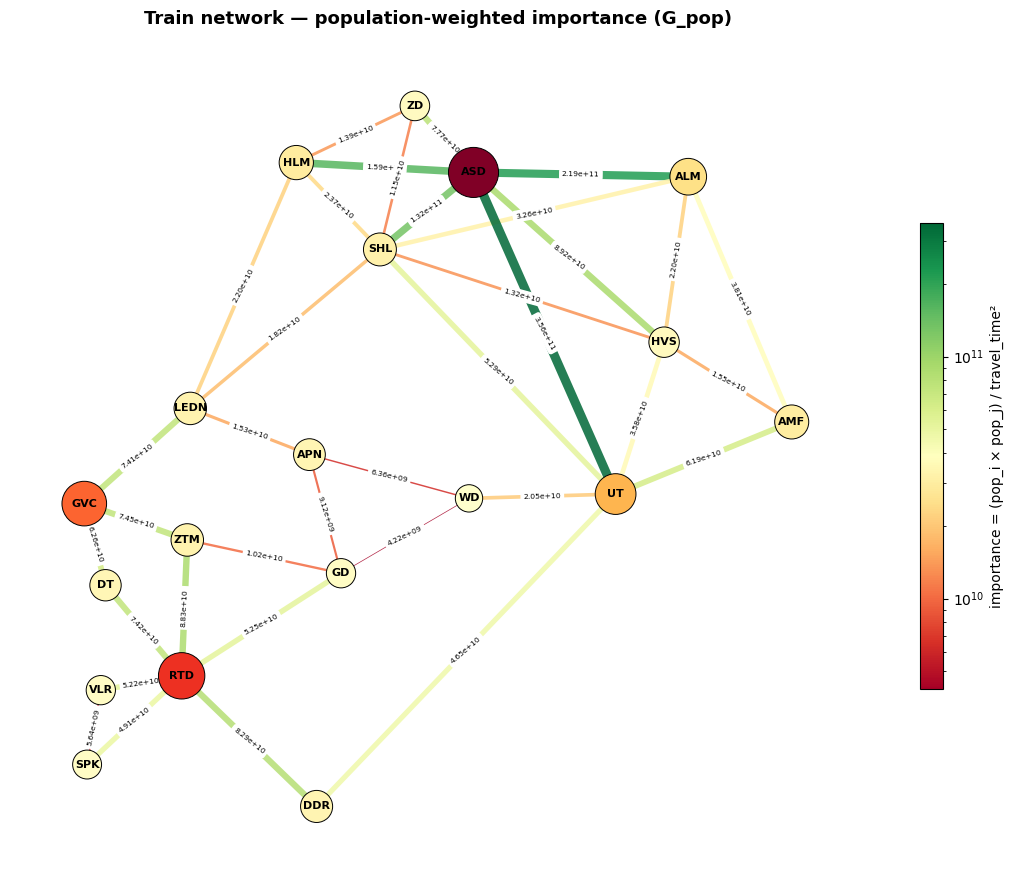

In [ ]:
fig, ax = plt.subplots(figsize=(11, 9))

pops  = np.array([G_pop.nodes[n]["population"] for n in G_pop.nodes()])
sizes = 100 + 1200 * (np.sqrt(pops) / np.sqrt(pops.max()))

importances = np.array([d["importance"] for _, _, d in G_pop.edges(data=True)])
norm        = mcolors.LogNorm(vmin=importances.min(), vmax=importances.max())
cmap        = cm.RdYlGn
edge_colors = [cmap(norm(v)) for v in importances]
edge_widths = [0.5 + 6.0 * norm(v) for v in importances]

nx.draw_networkx_edges(G_pop, pos, ax=ax,
                       edge_color=edge_colors, width=edge_widths, alpha=0.85)
nx.draw_networkx_nodes(G_pop, pos, ax=ax,
                       node_size=list(sizes),
                       node_color=list(pops),
                       cmap=cm.YlOrRd,
                       edgecolors="black", linewidths=0.7)
nx.draw_networkx_labels(G_pop, pos, ax=ax, font_size=8, font_weight="bold")

edge_labels = {(u, v): f"{d['importance']:.2e}" for u, v, d in G_pop.edges(data=True)}
nx.draw_networkx_edge_labels(G_pop, pos, edge_labels=edge_labels, font_size=5.5, ax=ax)

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, shrink=0.55,
             label="importance = (pop_i × pop_j) / travel_time²")

ax.set_title("Train network — population-weighted importance (G_pop)", fontsize=13, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
def evaluate_network_metrics_pop(network):
    for u, v, d in network.edges(data=True):
        network[u][v]['distance'] = 1 / d['importance']

    dcn         = nx.degree_centrality(network)
    ccn         = nx.closeness_centrality(network, distance='distance')
    bcn         = nx.betweenness_centrality(network, weight='distance', normalized=True)
    lcn         = nx.clustering(network, weight='weight')
    eigenvector = nx.eigenvector_centrality(network, weight='weight', max_iter=1000)

    metrics_df = pd.DataFrame({
        'Node':       list(network.nodes()),
        'Station':    [network.nodes[n]['station']    for n in network.nodes()],
        'Population': [network.nodes[n]['population'] for n in network.nodes()],
        'DCN':  [dcn[n]         for n in network.nodes()],
        'CCN':  [ccn[n]         for n in network.nodes()],
        'BCN':  [bcn[n]         for n in network.nodes()],
        'LCN':  [lcn[n]         for n in network.nodes()],
        'EC':   [eigenvector[n] for n in network.nodes()],
    })

    # Min-max normalise each metric to [0, 1]
    metric_cols = ['DCN', 'CCN', 'BCN', 'LCN', 'EC']
    for col in metric_cols:
        col_min = metrics_df[col].min()
        col_max = metrics_df[col].max()
        if col_max > col_min:  # avoid division by zero if all values are equal
            metrics_df[col] = (metrics_df[col] - col_min) / (col_max - col_min)

    metrics_df = metrics_df.round(4)
    return metrics_df.sort_values('DCN', ascending=False).reset_index(drop=True)

evaluate_network_metrics_pop(G_pop)

,Node,Station,Population,DCN,CCN,BCN,LCN,EC
0,SHL,Schiphol Airport,140000,1.0,0.7610,0.0000,0.5516,0.3890
1,UT,Utrecht Centraal,378140,0.8,1.0000,1.0000,0.4633,0.7698
2,ASD,Amsterdam Centraal,942504,0.8,0.9815,0.9487,1.0000,1.0000
3,RTD,Rotterdam Centraal,674500,0.8,0.9460,1.0000,0.0929,0.0114
4,HVS,Hilversum,94601,0.6,0.6587,0.0000,0.7835,0.2585
5,HLM,Haarlem,168946,0.4,0.8381,0.1667,0.6589,0.3304
6,LEDN,Leiden Centraal,130298,0.4,0.5417,0.2179,0.0813,0.0274
7,ALM,Almere Centrum,232650,0.4,0.8304,0.0000,0.8378,0.4684
8,GD,Gouda,77803,0.4,0.5029,0.0000,0.1627,0.0004
9,APN,Alphen a/d Rijn,117278,0.2,0.0000,0.0000,0.0480,0.0000
